In [81]:
# import libraries for lecture
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# import libraries for vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

# import libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix

In [4]:
# read our JSON file
df = pd.read_json("recipe_data.json")
df

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ..."
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b..."
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli..."


In [5]:
# explore our df
df.isnull().sum()

id             0
cuisine        0
ingredients    0
dtype: int64

In [9]:
# see if there are duplicates
len(df['id'].unique())

39774

In [13]:
# get a value count of the cuisine
df['cuisine'].value_counts()

italian         7838
mexican         6438
southern_us     4320
indian          3003
chinese         2673
french          2646
cajun_creole    1546
thai            1539
japanese        1423
greek           1175
spanish          989
korean           830
vietnamese       825
moroccan         821
british          804
filipino         755
irish            667
jamaican         526
russian          489
brazilian        467
Name: cuisine, dtype: int64

In [14]:
cuisine_list = df['cuisine'].value_counts().index
cuisine_list

Index(['italian', 'mexican', 'southern_us', 'indian', 'chinese', 'french',
       'cajun_creole', 'thai', 'japanese', 'greek', 'spanish', 'korean',
       'vietnamese', 'moroccan', 'british', 'filipino', 'irish', 'jamaican',
       'russian', 'brazilian'],
      dtype='object')

In [27]:
sns.color_palette("Set2", 6)

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
 (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
 (1.0, 0.8509803921568627, 0.1843137254901961)]

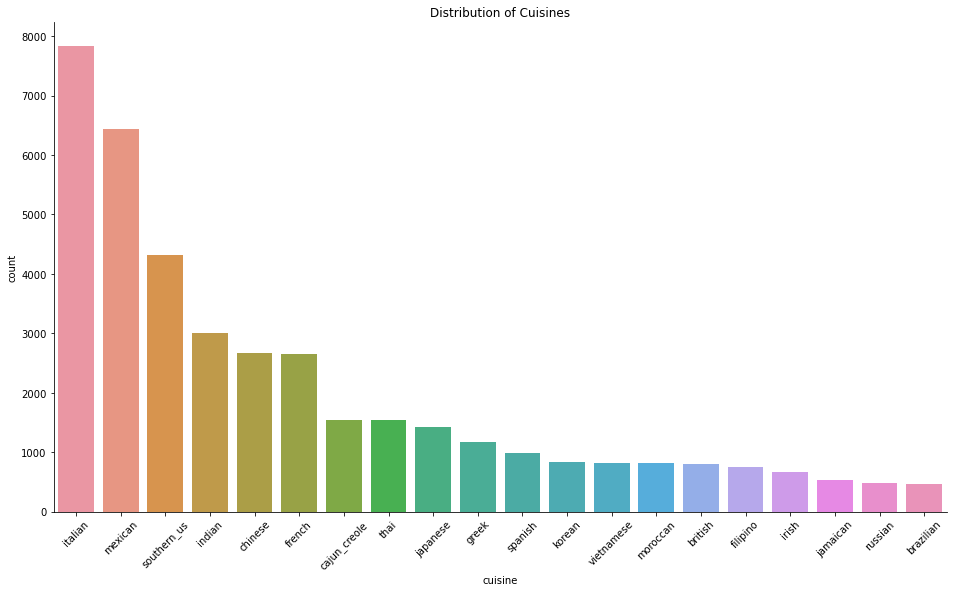

In [34]:
# plot a countplot to visualize cuisine distribution
plt.figure(figsize = (16, 9))
plt.xticks(rotation = 45)
plt.title("Distribution of Cuisines")
sns.countplot(df['cuisine'], order = cuisine_list)
sns.despine()

In [38]:
# let's take a look at the first row of df
df.iloc[0]['ingredients']

['romaine lettuce',
 'black olives',
 'grape tomatoes',
 'garlic',
 'pepper',
 'purple onion',
 'seasoning',
 'garbanzo beans',
 'feta cheese crumbles']

In [42]:
# create a new column that tells you how many items there are
# we will use .apply with len() to get the length of each row's list
df['num_of_ingredients'] = df['ingredients'].apply(len)
df

,id,cuisine,ingredients,num_of_ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes...",9
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g...",11
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g...",12
3,22213,indian,"[water, vegetable oil, wheat, salt]",4
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe...",20
...,...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ...",12
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b...",7
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte...",12
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli...",21


In [43]:
df['num_of_ingredients'].describe()

count    39774.000000
mean        10.767713
std          4.428978
min          1.000000
25%          8.000000
50%         10.000000
75%         13.000000
max         65.000000
Name: num_of_ingredients, dtype: float64

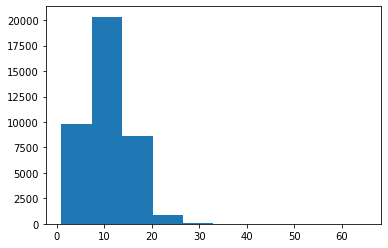

In [45]:
plt.hist(df['num_of_ingredients'])
plt.show()

In [46]:
# take a quick look at our large recipes
df[df['num_of_ingredients'] > 40]

,id,cuisine,ingredients,num_of_ingredients
10513,49282,mexican,"[condensed cream of chicken soup, pepper, refr...",49
15289,3885,italian,"[fettucine, fresh marjoram, minced garlic, oli...",65
22906,2253,indian,"[white vinegar, sparkling lemonade, coconut su...",49
26103,13049,mexican,"[vanilla ice cream, lime, garlic powder, zucch...",52
30350,13430,brazilian,"[marshmallows, fresh corn, cheddar cheese, shr...",59
31250,29216,italian,"[eggs, warm water, pepper, dried basil, unsalt...",43


In [48]:
df.iloc[15289]['ingredients']

['fettucine',
 'fresh marjoram',
 'minced garlic',
 'olive oil',
 'garlic powder',
 'large eggs',
 'Alfredo sauce',
 'vegetable oil',
 'cajun seasoning',
 'shredded romano cheese',
 'basil dried leaves',
 'salt',
 'cayenne pepper',
 'scallions',
 'red bell pepper',
 'boneless skinless chicken breast halves',
 'soba',
 'pasta sauce',
 'kosher salt',
 'milk',
 'fresh ginger',
 'ground black pepper',
 'flour',
 'cooked chicken',
 'coarse salt',
 'lemon',
 'diced tomatoes',
 'garlic',
 'rice vinegar',
 'Neufchâtel',
 'garlic cloves',
 'dried parsley',
 'frozen artichoke hearts',
 'penne',
 'pepper',
 'sweet onion',
 'part-skim mozzarella cheese',
 'parmigiano reggiano cheese',
 'basil leaves',
 'onion powder',
 'red wine vinegar',
 'red pepper flakes',
 'orzo',
 'crushed red pepper',
 'all-purpose flour',
 'freshly ground pepper',
 'sliced mushrooms',
 'panko breadcrumbs',
 'plum tomatoes',
 'fresh basil',
 'fresh leav spinach',
 'water',
 'sun-dried tomatoes',
 'ground pepper',
 'grated p

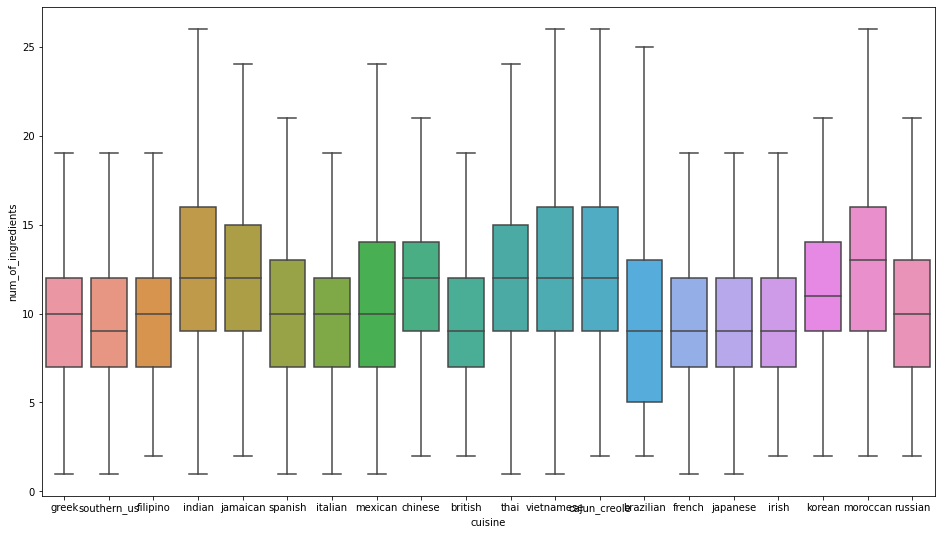

In [53]:
# let's plot num_of_ingredients vs cuisine
# yes we use a boxplot
plt.figure(figsize = (16, 9))
sns.boxplot(df['cuisine'], df['num_of_ingredients'], showfliers = False)

In [54]:
# look at weird rows
df[df['num_of_ingredients'] == 1]

,id,cuisine,ingredients,num_of_ingredients
940,4734,japanese,[sushi rice],1
2088,7833,vietnamese,[dried rice noodles],1
6787,36818,indian,[plain low-fat yogurt],1
7011,19772,indian,[unsalted butter],1
8181,16116,japanese,[udon],1
8852,29738,thai,[sticky rice],1
8990,41124,indian,[butter],1
10506,32631,mexican,[corn tortillas],1
13178,29570,thai,[grained],1
17804,29849,southern_us,[lemonade concentrate],1


In [55]:
# remove rows with 1 ingredient only
df = df[df['num_of_ingredients'] > 1]
df

,id,cuisine,ingredients,num_of_ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes...",9
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g...",11
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g...",12
3,22213,indian,"[water, vegetable oil, wheat, salt]",4
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe...",20
...,...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ...",12
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b...",7
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte...",12
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli...",21


In [64]:
# build a new DataFrame containing a single ingredient per row
ingredients = []
cuisines = []
id_values = []

for _, row in df.iterrows():
    temp_cuisine = row['cuisine']
    temp_id = row['id']
    
    # loop through each ingredient in the list in each row
    for ingredient in row['ingredients']:
        id_values.append(temp_id)
        cuisines.append(temp_cuisine)
        ingredients.append(ingredient)
        
df_cuisines_ingredients = pd.DataFrame({'id': id_values,
                                        'cuisines': cuisines,
                                        'ingredients': ingredients})

df_cuisines_ingredients

,id,cuisines,ingredients
0,10259,greek,romaine lettuce
1,10259,greek,black olives
2,10259,greek,grape tomatoes
3,10259,greek,garlic
4,10259,greek,pepper
...,...,...,...
428248,2362,mexican,garlic
428249,2362,mexican,white sugar
428250,2362,mexican,roma tomatoes
428251,2362,mexican,celery


In [66]:
# let's take a look at the distribution of ingredients
df_cuisines_ingredients['ingredients'].value_counts()[:50]

salt                      18049
olive oil                  7972
onions                     7972
water                      7456
garlic                     7380
sugar                      6434
garlic cloves              6237
butter                     4846
ground black pepper        4785
all-purpose flour          4632
pepper                     4438
vegetable oil              4384
eggs                       3388
soy sauce                  3296
kosher salt                3113
green onions               3078
tomatoes                   3058
large eggs                 2948
carrots                    2814
unsalted butter            2779
ground cumin               2747
extra-virgin olive oil     2747
black pepper               2627
milk                       2263
chili powder               2036
oil                        1970
red bell pepper            1939
purple onion               1896
scallions                  1891
grated parmesan cheese     1886
sesame oil                 1773
corn sta

In [78]:
df_cuisines_ingredients[df_cuisines_ingredients['cuisines'] == 'indian']['ingredients'].value_counts()

salt               1934
onions             1195
garam masala        862
water               820
ground turmeric     728
                   ... 
shucked oysters       1
roast beef            1
lamb fillet           1
vegan yogurt          1
salt water            1
Name: ingredients, Length: 1664, dtype: int64

In [ ]:
# come back at 710pm

# TF-IDF score

Sentence A : The car is driven on the road.

Sentence B: The truck is driven on the highway.

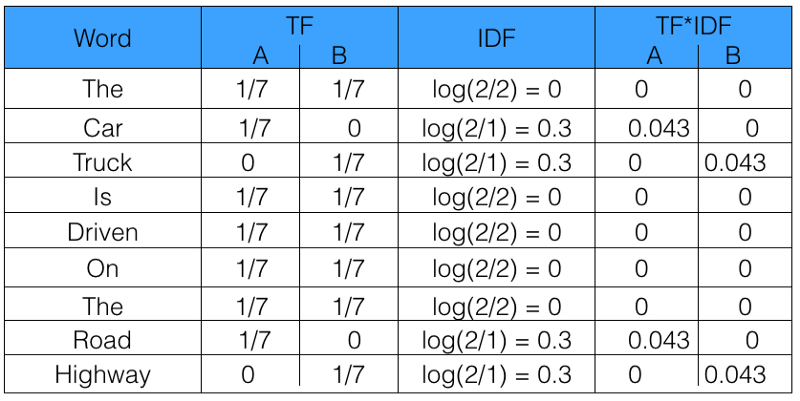

In [77]:
df

,id,cuisine,ingredients,num_of_ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes...",9
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g...",11
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g...",12
3,22213,indian,"[water, vegetable oil, wheat, salt]",4
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe...",20
...,...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ...",12
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b...",7
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte...",12
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli...",21


In [79]:
ingredient_strings = []

for ingredient in df['ingredients']:
    ingredient_string = " ".join(ingredient)
    ingredient_strings.append(ingredient_string)
    
df['ingredient_strings'] = ingredient_strings
df

<ipython-input-79-163980e030c8>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ingredient_strings'] = ingredient_strings


,id,cuisine,ingredients,num_of_ingredients,ingredient_strings
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes...",9,romaine lettuce black olives grape tomatoes ga...
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g...",11,plain flour ground pepper salt tomatoes ground...
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g...",12,eggs pepper salt mayonaise cooking oil green c...
3,22213,indian,"[water, vegetable oil, wheat, salt]",4,water vegetable oil wheat salt
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe...",20,black pepper shallots cornflour cayenne pepper...
...,...,...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ...",12,light brown sugar granulated sugar butter warm...
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b...",7,KRAFT Zesty Italian Dressing purple onion broc...
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte...",12,eggs citrus fruit raisins sourdough starter fl...
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli...",21,boneless chicken skinless thigh minced garlic ...


In [103]:
# declare a vectorizer object to vectorize our strings into a Tfidf vector
vectorizer = TfidfVectorizer(max_features = 500)

# use the vectorizer to transform our string ingredient column 
vectors = vectorizer.fit_transform(df['ingredient_strings'])

vectors

<39752x200 sparse matrix of type '<class 'numpy.float64'>'
	with 620479 stored elements in Compressed Sparse Row format>

In [104]:
# for N rows, max number of features is N/50

In [105]:
# turn our sparse matrix into a proper numpy array
vector_array = vectors.toarray()

# get feature names from the vectorizer
feature_names = vectorizer.get_feature_names()

In [106]:
# create a dataframe from our array and feature names
df_vectors = pd.DataFrame(vector_array, columns = feature_names)
df_vectors

,all,almonds,avocado,baby,bacon,baking,basil,bay,beans,beef,...,whites,whole,wine,worcestershire,yeast,yellow,yogurt,yolks,zest,zucchini
0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.326159,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
1,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.299518,0.000000,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.297977,0.000000,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.232615,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.266878,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39747,0.185432,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.237434,0.000000,0.0,0.296145,0.000000,0.000000,0.0,0.0,0.0
39748,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
39749,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0
39750,0.000000,0.0,0.0,0.0,0.0,0.329206,0.0,0.000000,0.000000,0.0,...,0.206223,0.000000,0.141521,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [107]:
# prepare our independent and dependent variables
X = df_vectors
y = df['cuisine']

# split our data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [108]:
# train a model with a DummyClassifier
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

In [109]:
# assess DummyClassifier performance
print(f1_score(y_test, dummy_pred, average = 'weighted'))

#pd.DataFrame(confusion_matrix(y_test, dummy_pred))

0.06496942633806453


In [110]:
logr = LogisticRegression(max_iter = 10000)
logr.fit(X_train, y_train)
logr_pred = logr.predict(X_test)

In [112]:
print(f1_score(y_test, logr_pred, average = 'weighted'))

#pd.DataFrame(confusion_matrix(y_test, logr_pred))

0.6810845375397042


In [113]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [115]:
f1_score(y_test, rf_pred, average = 'weighted')

0.6837773075925737

In [ ]:
# try to vectorize and predict your own dishes
"crab chili salt"